[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)

# Ensemble Methods for Tabular Data

This notebook provides a comprehensive introduction to ensemble learning—one of the most powerful and practical techniques in machine learning. We'll build intuition from first principles, implement key algorithms, and develop the interpretability skills that make tree-based models so valuable in practice.

**Why should you care about ensemble methods?**

For tabular/structured data (spreadsheets, databases, CSV files), ensemble tree methods consistently outperform or match deep learning approaches while being:
- **Faster to train** (no GPU required)
- **Easier to interpret** (feature importance, decision paths)
- **More robust** (handle missing values, outliers, mixed data types naturally)
- **Less finicky** (fewer hyperparameters to tune)

As Jeremy Howard notes: *"For structured/tabular data, tree ensembles are generally the better starting point over deep learning."*

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** why combining weak learners creates strong predictors (the mathematical intuition)
2. **Implement** voting ensembles and understand when they help
3. **Apply** bagging and understand how bootstrap sampling reduces variance
4. **Master** Random Forests including their key hyperparameters
5. **Interpret** models using feature importance, permutation importance, and partial dependence
6. **Assess** prediction confidence using tree disagreement
7. **Understand** the extrapolation limitation of tree-based methods
8. **Compare** Random Forests vs Gradient Boosting and know when to use each

---

## 1. Why Ensembles? The Wisdom of Crowds

### The Problem with Single Models

Single models suffer from fundamental limitations:

| Problem | Description | Example |
|---------|-------------|----------|
| **High Variance** | Small changes in data → large changes in predictions | Deep decision trees |
| **High Bias** | Model too simple to capture patterns | Linear regression on nonlinear data |
| **Noise Sensitivity** | Outliers disproportionately affect predictions | Single decision tree |

### The Core Insight: Error Diversification

The key insight behind ensembles is beautifully simple:

> **If each model is better than random guessing and makes *different* mistakes, combining them yields higher accuracy.**

Think of it like asking 10 experts for their opinion. Even if each expert is imperfect, if their errors are *uncorrelated*, averaging their answers cancels out individual mistakes while preserving the true signal.

### Mathematical Intuition

Let's make this concrete. Suppose we have $n$ independent classifiers, each with error rate $\epsilon$ (probability of being wrong). For a majority vote to be wrong, more than half the classifiers must be wrong simultaneously.

Using the binomial distribution, the ensemble error probability is:

$$P(\text{ensemble wrong}) = \sum_{k=\lceil n/2 \rceil}^{n} \binom{n}{k} \epsilon^k (1-\epsilon)^{n-k}$$

**Example:** With 11 classifiers each having 25% error rate:
- Individual error: 25%
- Ensemble error: **3.4%**

That's a dramatic improvement! Let's verify this computationally.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb
import math

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, BaggingRegressor
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
def ensemble_error(n_classifiers, base_error):
    """Calculate ensemble error probability using binomial distribution.
    
    For a majority vote to be wrong, more than half the classifiers must err.
    """
    k_start = int(math.ceil(n_classifiers / 2.0))
    probs = [
        comb(n_classifiers, k) * base_error**k * (1 - base_error)**(n_classifiers - k)
        for k in range(k_start, n_classifiers + 1)
    ]
    return sum(probs)

# Verify our example: 11 classifiers, 25% error each
print(f"Individual classifier error: 25.0%")
print(f"Ensemble of 11 classifiers:  {ensemble_error(11, 0.25)*100:.1f}%")
print(f"\nThat's a {(0.25 - ensemble_error(11, 0.25))/0.25*100:.0f}% reduction in error rate!")

Individual classifier error: 25.0%
Ensemble of 11 classifiers:  3.4%

That's a 86% reduction in error rate!


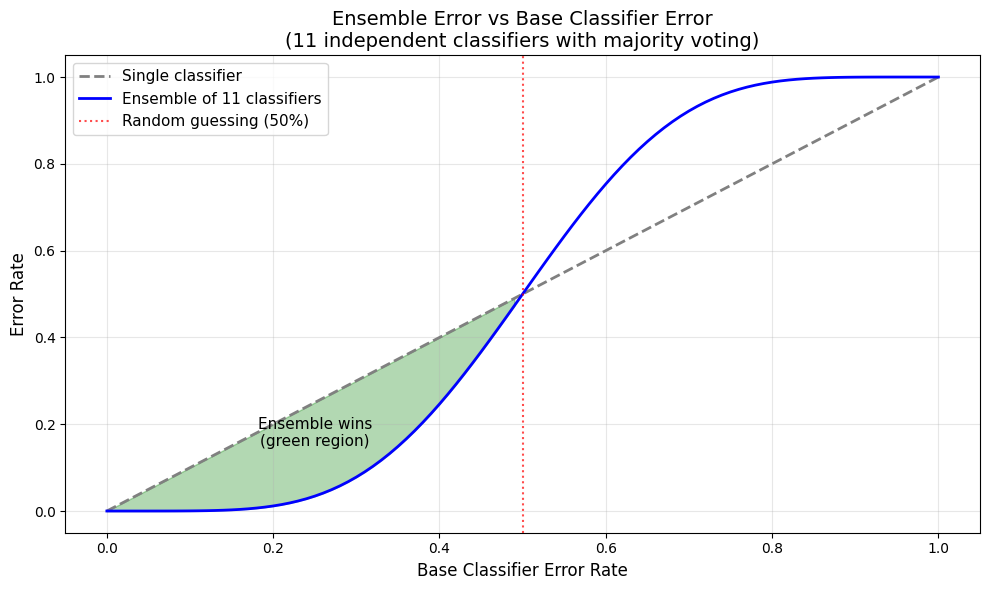

Key insight: As long as each classifier is better than random guessing (error < 50%),
the ensemble will outperform individual classifiers.


In [3]:
# Visualize how ensemble error relates to base error
error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(11, e) for e in error_range]

plt.figure(figsize=(10, 6))
plt.plot(error_range, error_range, '--', label='Single classifier', linewidth=2, color='gray')
plt.plot(error_range, ens_errors, label='Ensemble of 11 classifiers', linewidth=2, color='blue')
plt.axvline(x=0.5, color='red', linestyle=':', alpha=0.7, label='Random guessing (50%)')
plt.fill_between(error_range[:50], error_range[:50], ens_errors[:50], alpha=0.3, color='green')

plt.xlabel('Base Classifier Error Rate', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.title('Ensemble Error vs Base Classifier Error\n(11 independent classifiers with majority voting)', fontsize=14)
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.annotate('Ensemble wins\n(green region)', xy=(0.25, 0.15), fontsize=11, ha='center')
plt.tight_layout()
plt.show()

print("Key insight: As long as each classifier is better than random guessing (error < 50%),")
print("the ensemble will outperform individual classifiers.")

### The Critical Assumption: Independence

The mathematical magic above relies on a **crucial assumption**: the classifiers make *independent* errors. If all classifiers make the same mistakes, combining them won't help!

This is why ensemble methods work hard to create **diversity** among their base learners:

| Method | How it Creates Diversity |
|--------|-------------------------|
| **Voting** | Different algorithms (logistic regression, SVM, tree) |
| **Bagging** | Different random subsets of training data |
| **Random Forest** | Different data subsets AND different feature subsets |
| **Boosting** | Sequential focus on different "hard" examples |

---

## 2. Our Dataset: California Housing

We'll use the California Housing dataset throughout this notebook. It's a regression task: predict median house value from census data.

In [4]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

# Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("California Housing Dataset")
print("=" * 50)
print(f"Total samples: {len(X):,}")
print(f"Training: {len(X_train):,} | Validation: {len(X_valid):,}")
print(f"\nFeatures ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")
print(f"\nTarget: Median house value (in $100,000s)")
print(f"  Range: ${y.min()*100000:,.0f} - ${y.max()*100000:,.0f}")

California Housing Dataset
Total samples: 20,640
Training: 16,512 | Validation: 4,128

Features (8):
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

Target: Median house value (in $100,000s)
  Range: $14,999 - $500,001


In [ ]:
X.head()

---

## 3. Decision Trees: The Building Block

Before diving into ensembles, let's understand the base learner: **decision trees**.

### How Decision Trees Work

A decision tree recursively partitions the feature space by asking yes/no questions:

1. Loop through each feature
2. For each feature, test all possible split points
3. Select the split that best separates the target values (minimizes MSE for regression)
4. Repeat recursively on each partition until stopping criteria are met

### Why Trees Are "Unstable"

Decision trees have **high variance**: small changes in training data can lead to completely different trees. This is both a weakness (for single trees) and an opportunity (for ensembles that exploit this diversity).

In [5]:
# Train a single decision tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

train_r2 = r2_score(y_train, tree.predict(X_train))
valid_r2 = r2_score(y_valid, tree.predict(X_valid))

print("Single Decision Tree (max_depth=5)")
print("=" * 40)
print(f"Train R²: {train_r2:.4f}")
print(f"Valid R²: {valid_r2:.4f}")
print(f"\nGap (train - valid): {train_r2 - valid_r2:.4f}")
print("\nThis gap suggests the model is overfitting slightly.")

Single Decision Tree (max_depth=5)
Train R²: 0.6377
Valid R²: 0.5997

Gap (train - valid): 0.0379

This gap suggests the model is overfitting slightly.


In [ ]:
# Demonstrate tree instability: train on slightly different data
print("Tree Instability Demonstration")
print("=" * 50)
print("Training 5 trees on 90% random subsets of the same data:\n")

predictions = []
for i in range(5):
    # Sample 90% of training data
    idx = np.random.choice(len(X_train), size=int(0.9 * len(X_train)), replace=False)
    X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    
    t = DecisionTreeRegressor(max_depth=5, random_state=42)
    t.fit(X_sub, y_sub)
    pred = t.predict(X_valid)
    predictions.append(pred)
    r2 = r2_score(y_valid, pred)
    print(f"  Tree {i+1}: Valid R² = {r2:.4f}")

# Look at prediction variance
predictions = np.array(predictions)
pred_std = predictions.std(axis=0)
print(f"\nAverage prediction std across trees: {pred_std.mean():.4f}")
print(f"Max prediction std: {pred_std.max():.4f}")
print("\nThis variance is the 'instability' that ensembles exploit!")

---

## 4. Simple Voting Ensemble

The simplest ensemble: train multiple models and average their predictions (for regression) or take a majority vote (for classification).

Even this basic approach can help, especially when combining *different* algorithms that capture different patterns.

In [6]:
# Manual ensemble: average predictions from trees with different random states
print("Simple Voting Ensemble (20 trees, same algorithm, different seeds)")
print("=" * 60)

all_preds = []
individual_scores = []

for seed in range(20):
    t = DecisionTreeRegressor(max_depth=5, random_state=seed)
    t.fit(X_train, y_train)
    pred = t.predict(X_valid)
    all_preds.append(pred)
    individual_scores.append(r2_score(y_valid, pred))

# Ensemble prediction is the average
ensemble_pred = np.mean(all_preds, axis=0)
ensemble_r2 = r2_score(y_valid, ensemble_pred)

print(f"Individual tree R² scores: min={min(individual_scores):.4f}, max={max(individual_scores):.4f}")
print(f"Average individual R²: {np.mean(individual_scores):.4f}")
print(f"Ensemble R²: {ensemble_r2:.4f}")
print(f"\nImprovement over average: {(ensemble_r2 - np.mean(individual_scores))*100:.2f} percentage points")

Simple Voting Ensemble (20 trees, same algorithm, different seeds)
Individual tree R² scores: min=0.5997, max=0.5997
Average individual R²: 0.5997
Ensemble R²: 0.5997

Improvement over average: 0.00 percentage points


**Wait, the improvement is small!** That's because these trees, while using different random seeds, are trained on the *same data* and use the *same algorithm*. They're not diverse enough.

To get more diversity, we need **bagging**.

---

## 5. Bagging (Bootstrap Aggregating)

Bagging, invented by Leo Breiman in 1994, creates diversity by training each model on a **different random subset** of the training data.

### How Bagging Works

1. **Bootstrap sampling**: Draw $n$ samples from the training set *with replacement*
   - Some examples appear multiple times, others not at all
   - On average, each bootstrap sample contains ~63.2% unique examples
2. **Train** a model on each bootstrap sample
3. **Aggregate** predictions by averaging (regression) or voting (classification)

### Why It Works

Jeremy Howard explains it beautifully:

> *"Each tree is trained on a random subset of rows. Although each individual tree has errors, those errors are **random and uncorrelated**. The average of a group of random errors is zero, so these errors cancel out and what's left is the true relationship."*

Bagging reduces **variance** without increasing bias.

In [7]:
# Visualize bootstrap sampling
print("Bootstrap Sampling Demonstration")
print("=" * 50)
print("\nOriginal training set has indices: [0, 1, 2, 3, 4, 5, 6]")
print("\n3 bootstrap samples (with replacement):")

np.random.seed(42)
for i in range(3):
    bootstrap = np.random.choice(7, size=7, replace=True)
    unique = len(set(bootstrap))
    print(f"  Sample {i+1}: {list(bootstrap)} ({unique}/7 unique = {unique/7*100:.0f}%)")

print(f"\nTheoretical: ~63.2% unique samples per bootstrap (1 - 1/e)")

Bootstrap Sampling Demonstration

Original training set has indices: [0, 1, 2, 3, 4, 5, 6]

3 bootstrap samples (with replacement):
  Sample 1: [np.int64(6), np.int64(3), np.int64(4), np.int64(6), np.int64(2), np.int64(4), np.int64(4)] (4/7 unique = 57%)
  Sample 2: [np.int64(6), np.int64(1), np.int64(2), np.int64(6), np.int64(2), np.int64(2), np.int64(4)] (4/7 unique = 57%)
  Sample 3: [np.int64(3), np.int64(2), np.int64(5), np.int64(4), np.int64(1), np.int64(3), np.int64(5)] (5/7 unique = 71%)

Theoretical: ~63.2% unique samples per bootstrap (1 - 1/e)


In [8]:
# Apply bagging
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,
    max_samples=1.0,  # Use 100% of samples (with replacement)
    bootstrap=True,   # Sample with replacement
    random_state=42,
    n_jobs=-1
)
bag.fit(X_train, y_train)

bag_train_r2 = r2_score(y_train, bag.predict(X_train))
bag_valid_r2 = r2_score(y_valid, bag.predict(X_valid))

print("Bagging Results (50 trees, max_depth=5)")
print("=" * 45)
print(f"Train R²: {bag_train_r2:.4f}")
print(f"Valid R²: {bag_valid_r2:.4f}")
print(f"\nComparison to single tree:")
print(f"  Single tree valid R²: {valid_r2:.4f}")
print(f"  Bagging valid R²:     {bag_valid_r2:.4f}")
print(f"  Improvement: {(bag_valid_r2 - valid_r2)*100:.2f} percentage points")

Bagging Results (50 trees, max_depth=5)
Train R²: 0.6814
Valid R²: 0.6469

Comparison to single tree:
  Single tree valid R²: 0.5997
  Bagging valid R²:     0.6469
  Improvement: 4.71 percentage points


---

## 6. Random Forests: Bagging on Steroids

Random Forests (Breiman, 2001) extend bagging with one key innovation: **random feature selection at each split**.

### The Random Forest Algorithm

1. Draw a bootstrap sample of the training data
2. Grow a decision tree, but at each node:
   - Instead of considering ALL features for the best split
   - Randomly select a SUBSET of features (typically $\sqrt{p}$ for classification, $p/3$ for regression)
   - Find the best split among only those features
3. Repeat to build many trees
4. Average predictions (no pruning needed!)

### Why Random Feature Selection Helps

If one feature is very predictive (like `MedInc` for house prices), a regular bagging ensemble would use that feature at the root of every tree. The trees would be highly correlated, reducing the benefit of averaging.

By forcing each split to consider only a random subset of features, Random Forests ensure that different trees use different features, creating more diverse (and thus more valuable) predictions.

In [9]:
# Train a Random Forest
rf = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth per tree
    min_samples_leaf=5,    # Minimum samples in a leaf (prevents overfitting)
    max_features=0.5,      # Consider 50% of features at each split
    oob_score=True,        # Calculate out-of-bag score (explained below)
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)

rf_train_r2 = r2_score(y_train, rf.predict(X_train))
rf_valid_r2 = r2_score(y_valid, rf.predict(X_valid))
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf.predict(X_valid)))

print("Random Forest Results")
print("=" * 50)
print(f"Configuration: 100 trees, max_depth=10, max_features=50%")
print(f"\nTrain R²:  {rf_train_r2:.4f}")
print(f"Valid R²:  {rf_valid_r2:.4f}")
print(f"OOB R²:    {rf.oob_score_:.4f}  ← Free validation estimate!")
print(f"Valid RMSE: ${rf_rmse * 100000:,.0f}")
print(f"\nComparison:")
print(f"  Single tree:   {valid_r2:.4f}")
print(f"  Bagging:       {bag_valid_r2:.4f}")
print(f"  Random Forest: {rf_valid_r2:.4f}")

Random Forest Results
Configuration: 100 trees, max_depth=10, max_features=50%

Train R²:  0.8449
Valid R²:  0.7734
OOB R²:    0.7854  ← Free validation estimate!
Valid RMSE: $54,487

Comparison:
  Single tree:   0.5997
  Bagging:       0.6469
  Random Forest: 0.7734


### Out-of-Bag (OOB) Error: Free Validation!

Remember that each bootstrap sample excludes ~36.8% of training examples. These excluded examples are called the **out-of-bag** (OOB) samples for that tree.

For any training example, we can:
1. Find all trees where it was OOB (not in the bootstrap sample)
2. Average only those trees' predictions
3. Compare to the true value

This gives us an unbiased estimate of generalization error **without needing a separate validation set**—particularly valuable for small datasets!

The OOB score above (0.77) is very close to our validation R² (0.77), confirming it's a reliable estimate.

### Random Forest FAQ

**Q: Can you overfit a Random Forest by adding more trees?**

A: No! More trees = more averaging = more stable predictions. The error will plateau but never increase. (However, you can still overfit by making trees too deep.)

**Q: Should you remove poorly performing trees?**

A: No! Removing weak trees biases the ensemble. The whole point is that weak individual predictions average to strong ensemble predictions.

**Q: How many trees is enough?**

A: Typically 100-200 trees is sufficient. Returns diminish quickly—doubling from 100 to 200 trees might only improve accuracy by 0.1%.

How Many Trees Do We Need?
    1 trees: OOB R² = -1.8178
    5 trees: OOB R² = 0.3386
   10 trees: OOB R² = 0.7126
   20 trees: OOB R² = 0.7725
   50 trees: OOB R² = 0.7828
  100 trees: OOB R² = 0.7843
  200 trees: OOB R² = 0.7855


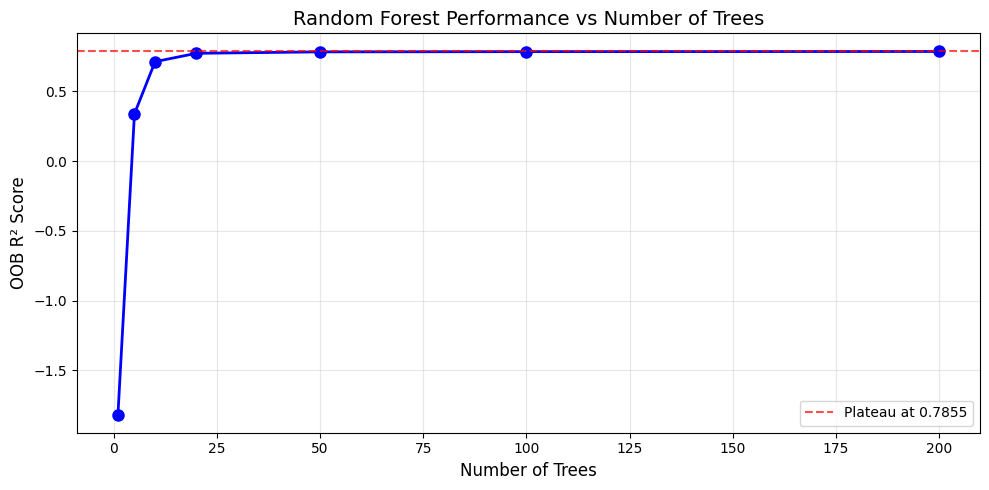


Notice: Most improvement comes from the first 50 trees.
After that, returns diminish rapidly.


In [10]:
# Show how error stabilizes with more trees
print("How Many Trees Do We Need?")
print("=" * 40)

n_trees_list = [1, 5, 10, 20, 50, 100, 200]
oob_scores = []

for n in n_trees_list:
    rf_temp = RandomForestRegressor(
        n_estimators=n, max_depth=10, min_samples_leaf=5,
        oob_score=True, n_jobs=-1, random_state=42
    )
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)
    print(f"  {n:3d} trees: OOB R² = {rf_temp.oob_score_:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(n_trees_list, oob_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('OOB R² Score', fontsize=12)
plt.title('Random Forest Performance vs Number of Trees', fontsize=14)
plt.grid(alpha=0.3)
plt.axhline(y=oob_scores[-1], color='red', linestyle='--', alpha=0.7, label=f'Plateau at {oob_scores[-1]:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nNotice: Most improvement comes from the first 50 trees.")
print("After that, returns diminish rapidly.")

---

## 7. Feature Importance: Which Features Matter?

One of the biggest advantages of tree-based models is **interpretability**. We can understand which features drive predictions.

### Impurity-Based Importance (Default in sklearn)

The default `feature_importances_` in sklearn measures how much each feature decreases impurity (MSE for regression) across all splits in all trees.

**Warning**: This method is biased toward high-cardinality and continuous features. A column of random numbers can appear important simply because it offers more potential split points!

In [11]:
# Default (impurity-based) feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (Impurity-Based)")
print("=" * 50)
print(importance_df.to_string(index=False))

Feature Importance (Impurity-Based)
   feature  importance
    MedInc    0.507191
  AveOccup    0.131386
  Latitude    0.102835
 Longitude    0.094216
  AveRooms    0.086947
  HouseAge    0.047630
 AveBedrms    0.019927
Population    0.009868


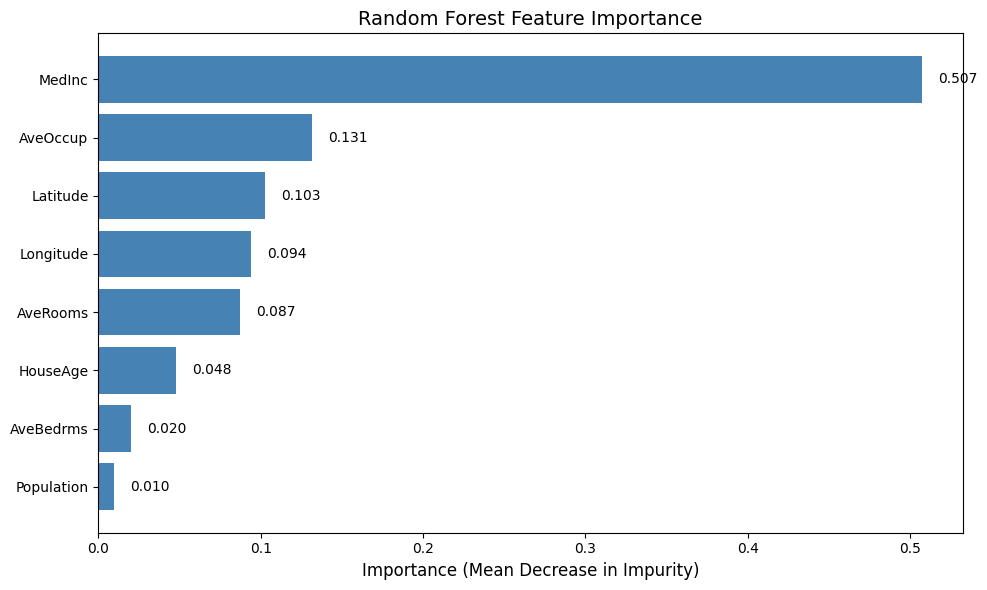


MedInc (Median Income) dominates—not surprising for house prices!


In [12]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=12)
ax.set_title('Random Forest Feature Importance', fontsize=14)
ax.invert_yaxis()  # Most important at top

# Add value labels
for bar, imp in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nMedInc (Median Income) dominates—not surprising for house prices!")

### Permutation Importance: The Better Method

A more reliable method is **permutation importance**:

1. Train the model and record baseline performance
2. For each feature:
   - Randomly shuffle that feature's values (breaking the relationship with the target)
   - Measure how much performance drops
3. Importance = performance drop when feature is shuffled

If shuffling a feature doesn't hurt performance, that feature isn't important!

**Advantages over impurity-based importance:**
- Works for any model (not just trees)
- Not biased toward high-cardinality features
- Computed on validation data, reflecting true predictive value

In [13]:
# Calculate permutation importance
perm_importance = permutation_importance(
    rf, X_valid, y_valid, 
    n_repeats=10,  # Shuffle each feature 10 times
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("Permutation Importance (on validation set)")
print("=" * 55)
print("Feature          Mean Importance  Std")
print("-" * 55)
for _, row in perm_df.iterrows():
    print(f"{row['feature']:15s}  {row['importance_mean']:.4f}          ±{row['importance_std']:.4f}")

Permutation Importance (on validation set)
Feature          Mean Importance  Std
-------------------------------------------------------
MedInc           0.7212          ±0.0140
Latitude         0.2480          ±0.0044
AveOccup         0.1834          ±0.0047
Longitude        0.1792          ±0.0037
HouseAge         0.0529          ±0.0028
AveRooms         0.0268          ±0.0019
AveBedrms        0.0045          ±0.0007
Population       0.0022          ±0.0002


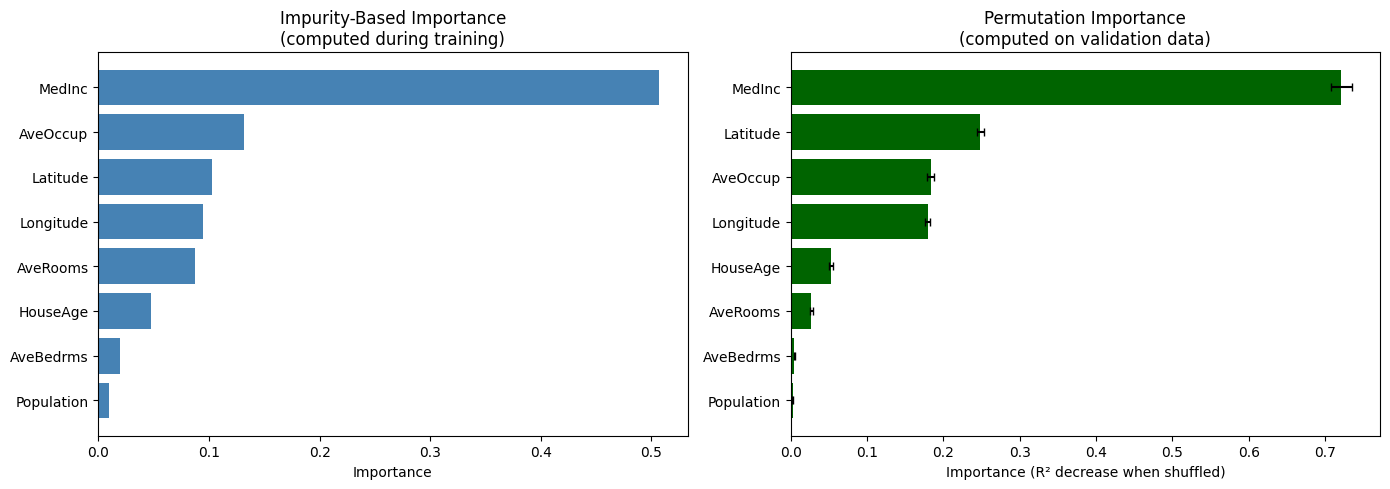

Both methods agree that MedInc and geographic features (Lat/Long) are most important.
Permutation importance provides error bars, showing uncertainty in the estimates.


In [14]:
# Compare both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Impurity-based
axes[0].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Impurity-Based Importance\n(computed during training)', fontsize=12)
axes[0].invert_yaxis()

# Permutation-based
axes[1].barh(perm_df['feature'], perm_df['importance_mean'], 
             xerr=perm_df['importance_std'], color='darkgreen', capsize=3)
axes[1].set_xlabel('Importance (R² decrease when shuffled)')
axes[1].set_title('Permutation Importance\n(computed on validation data)', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Both methods agree that MedInc and geographic features (Lat/Long) are most important.")
print("Permutation importance provides error bars, showing uncertainty in the estimates.")

---

## 8. Partial Dependence: How Features Affect Predictions

Feature importance tells us *which* features matter, but not *how* they affect predictions.

**Partial Dependence Plots (PDPs)** show the marginal effect of a feature on predictions:

1. Fix the feature of interest at a specific value
2. For all training examples, replace that feature with the fixed value
3. Average the model's predictions
4. Repeat for many values of the feature
5. Plot average prediction vs feature value

This shows the relationship between a feature and predictions, **holding all other features constant** (on average).

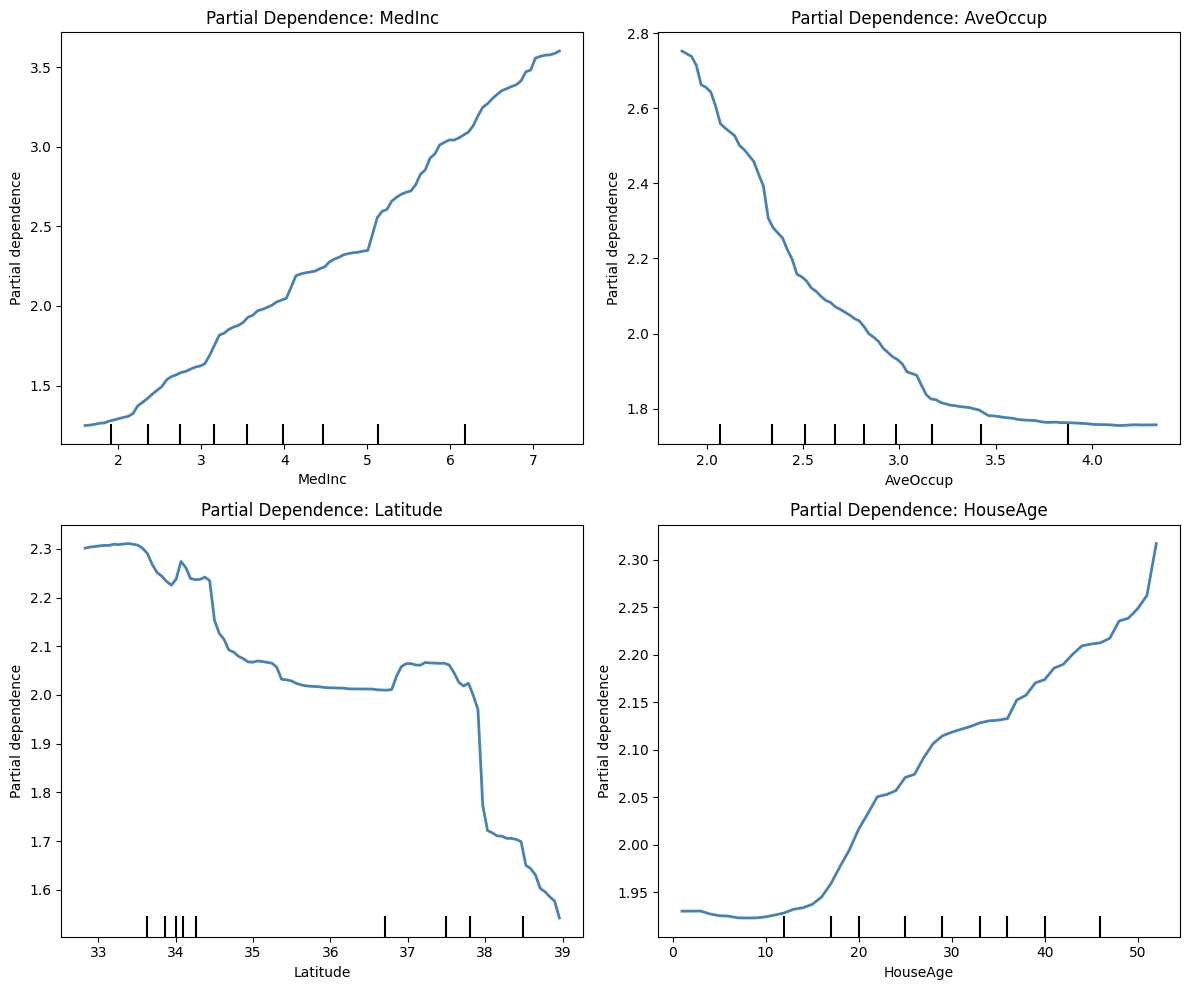

Interpretations:
- MedInc: Strong positive relationship—higher income areas have higher house values
- AveOccup: Negative effect when occupancy is high (crowded areas = lower values)
- Latitude: Interesting pattern—different regions have different price levels
- HouseAge: Mild effect—newer houses slightly more valuable, with some variation


In [15]:
# Create partial dependence plots for top features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

top_features = ['MedInc', 'AveOccup', 'Latitude', 'HouseAge']

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    PartialDependenceDisplay.from_estimator(
        rf, X_train, [feature], ax=ax, 
        line_kw={'color': 'steelblue', 'linewidth': 2}
    )
    ax.set_title(f'Partial Dependence: {feature}', fontsize=12)
    ax.set_ylabel('Predicted House Value')

plt.tight_layout()
plt.show()

print("Interpretations:")
print("- MedInc: Strong positive relationship—higher income areas have higher house values")
print("- AveOccup: Negative effect when occupancy is high (crowded areas = lower values)")
print("- Latitude: Interesting pattern—different regions have different price levels")
print("- HouseAge: Mild effect—newer houses slightly more valuable, with some variation")

---

## 9. Prediction Confidence: When to Trust Your Model

A powerful (and often overlooked) advantage of Random Forests: you can estimate **confidence** in predictions by looking at how much individual trees disagree.

- **Low variance** across trees → trees agree → high confidence (likely similar to training data)
- **High variance** across trees → trees disagree → low confidence (likely unusual input)

This is essentially a free uncertainty estimate!

In [16]:
# Get predictions from each individual tree
tree_preds = np.array([tree.predict(X_valid) for tree in rf.estimators_])

# Calculate mean and std across trees for each sample
pred_mean = tree_preds.mean(axis=0)
pred_std = tree_preds.std(axis=0)

# Analyze prediction confidence
print("Prediction Confidence Analysis")
print("=" * 50)
print(f"Average prediction std: {pred_std.mean():.4f}")
print(f"Min prediction std:     {pred_std.min():.4f} (highest confidence)")
print(f"Max prediction std:     {pred_std.max():.4f} (lowest confidence)")

# Find high and low confidence examples
high_conf_idx = np.argmin(pred_std)
low_conf_idx = np.argmax(pred_std)

print(f"\nHighest confidence prediction:")
print(f"  Predicted: ${pred_mean[high_conf_idx]*100000:,.0f} ± ${pred_std[high_conf_idx]*100000:,.0f}")
print(f"  Actual:    ${y_valid.iloc[high_conf_idx]*100000:,.0f}")

print(f"\nLowest confidence prediction:")
print(f"  Predicted: ${pred_mean[low_conf_idx]*100000:,.0f} ± ${pred_std[low_conf_idx]*100000:,.0f}")
print(f"  Actual:    ${y_valid.iloc[low_conf_idx]*100000:,.0f}")

Prediction Confidence Analysis
Average prediction std: 0.3386
Min prediction std:     0.0246 (highest confidence)
Max prediction std:     1.1040 (lowest confidence)

Highest confidence prediction:
  Predicted: $498,877 ± $2,462
  Actual:    $500,001

Lowest confidence prediction:
  Predicted: $311,525 ± $110,402
  Actual:    $383,300


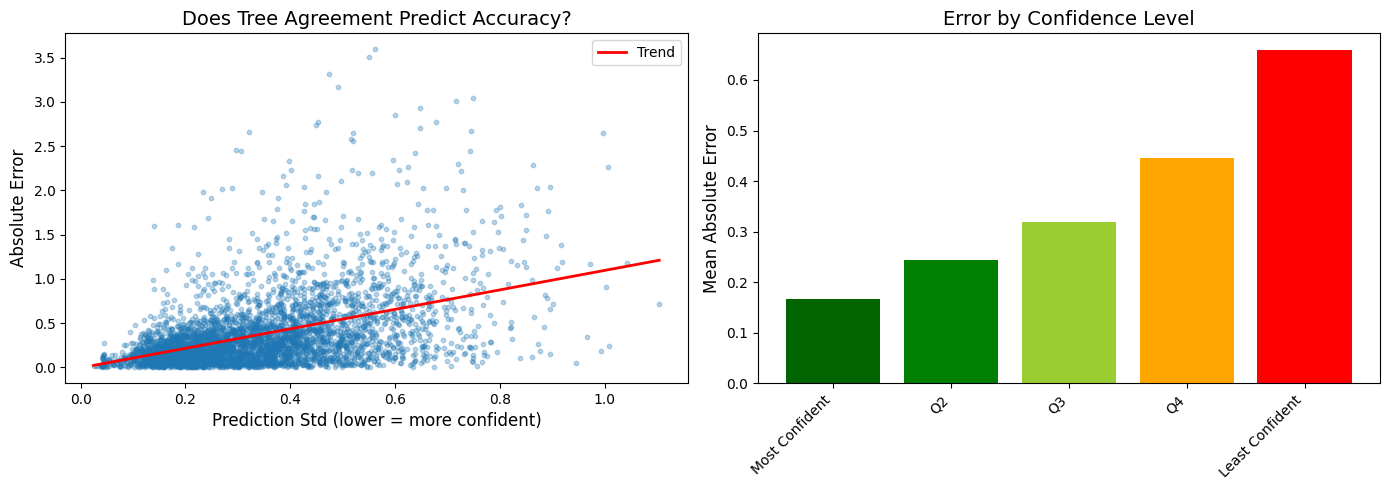

Conclusion: When trees agree (low std), predictions are more accurate.
This confidence measure can flag predictions that need human review!


In [17]:
# Plot: Does higher confidence correlate with lower error?
errors = np.abs(pred_mean - y_valid.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(pred_std, errors, alpha=0.3, s=10)
axes[0].set_xlabel('Prediction Std (lower = more confident)', fontsize=12)
axes[0].set_ylabel('Absolute Error', fontsize=12)
axes[0].set_title('Does Tree Agreement Predict Accuracy?', fontsize=14)

# Add trend line
z = np.polyfit(pred_std, errors, 1)
p = np.poly1d(z)
x_line = np.linspace(pred_std.min(), pred_std.max(), 100)
axes[0].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend')
axes[0].legend()

# Binned analysis
bins = pd.qcut(pred_std, q=5, labels=['Most Confident', 'Q2', 'Q3', 'Q4', 'Least Confident'])
error_by_conf = pd.DataFrame({'bin': bins, 'error': errors}).groupby('bin')['error'].mean()

axes[1].bar(range(5), error_by_conf.values, color=['darkgreen', 'green', 'yellowgreen', 'orange', 'red'])
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(error_by_conf.index, rotation=45, ha='right')
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('Error by Confidence Level', fontsize=14)

plt.tight_layout()
plt.show()

print("Conclusion: When trees agree (low std), predictions are more accurate.")
print("This confidence measure can flag predictions that need human review!")

---

## 10. The Extrapolation Problem: Where Trees Fail

**Critical limitation**: Random Forests cannot extrapolate beyond the range of training data. They can only output values they've seen during training.

Why? Trees make predictions by averaging values in leaf nodes. If all training house prices are between \$50K and \$500K, the model can never predict \$600K—even if the features clearly indicate an expensive house.

This matters for:
- Time series with trends (prices rising over time)
- New markets/regions not in training data
- Extrapolating to extreme feature values

Neural networks, being smooth functions, CAN extrapolate (though not always correctly).

Extrapolation Problem Demonstration


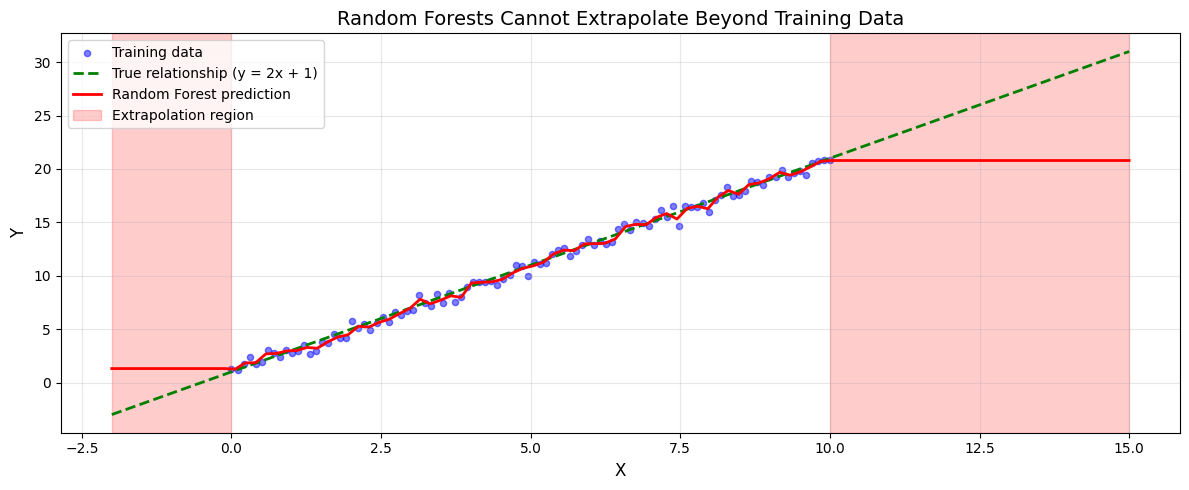

Notice: In the red regions (outside training data), the RF predicts
flat values equal to the nearest training data, not the true trend!


In [18]:
# Demonstrate the extrapolation problem
print("Extrapolation Problem Demonstration")
print("=" * 50)

# Create a simple 1D dataset with a linear trend
np.random.seed(42)
x_train = np.linspace(0, 10, 100).reshape(-1, 1)
y_train_lin = 2 * x_train.flatten() + 1 + np.random.randn(100) * 0.5

# Test data includes extrapolation region
x_test = np.linspace(-2, 15, 100).reshape(-1, 1)
y_true = 2 * x_test.flatten() + 1

# Fit Random Forest
rf_demo = RandomForestRegressor(n_estimators=100, random_state=42)
rf_demo.fit(x_train, y_train_lin)
y_pred_rf = rf_demo.predict(x_test)

# Plot
plt.figure(figsize=(12, 5))

# Training data
plt.scatter(x_train, y_train_lin, alpha=0.5, s=20, label='Training data', color='blue')

# True relationship
plt.plot(x_test, y_true, 'g--', linewidth=2, label='True relationship (y = 2x + 1)')

# RF prediction
plt.plot(x_test, y_pred_rf, 'r-', linewidth=2, label='Random Forest prediction')

# Highlight extrapolation regions
plt.axvspan(-2, 0, alpha=0.2, color='red', label='Extrapolation region')
plt.axvspan(10, 15, alpha=0.2, color='red')

plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Random Forests Cannot Extrapolate Beyond Training Data', fontsize=14)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: In the red regions (outside training data), the RF predicts")
print("flat values equal to the nearest training data, not the true trend!")

---

## 11. Hyperparameter Tuning

Random Forests are relatively insensitive to hyperparameters, but tuning can still help.

### Key Hyperparameters

| Parameter | Description | Typical Range | Effect |
|-----------|-------------|---------------|--------|
| `n_estimators` | Number of trees | 100-500 | More = better (diminishing returns) |
| `max_depth` | Max tree depth | 10-30 or None | Deeper = more complex, risk overfitting |
| `min_samples_leaf` | Min samples per leaf | 1-20 | Higher = more regularization |
| `max_features` | Features per split | 'sqrt', 0.3-0.5 | Lower = more diverse trees |

In [19]:
# Quick hyperparameter comparison
print("Hyperparameter Comparison")
print("=" * 70)
print(f"{'Config':<40} {'OOB R²':>10} {'Valid R²':>10}")
print("-" * 70)

configs = [
    {'n_estimators': 50, 'max_depth': 5, 'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},  # No limits
]

for config in configs:
    model = RandomForestRegressor(**config, oob_score=True, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    valid_score = r2_score(y_valid, model.predict(X_valid))
    config_str = f"trees={config['n_estimators']}, depth={config['max_depth']}, leaf={config['min_samples_leaf']}"
    print(f"{config_str:<40} {model.oob_score_:>10.4f} {valid_score:>10.4f}")

print("\nObservation: More trees and deeper trees generally help, but the")
print("improvement becomes marginal. The simplest model (first row) already does well!")

Hyperparameter Comparison
Config                                       OOB R²   Valid R²
----------------------------------------------------------------------
trees=50, depth=5, leaf=10                   0.6621     0.6466
trees=100, depth=10, leaf=5                  0.7843     0.7743
trees=200, depth=15, leaf=2                  0.8080     0.8031
trees=200, depth=None, leaf=1                0.8099     0.8062

Observation: More trees and deeper trees generally help, but the
improvement becomes marginal. The simplest model (first row) already does well!


---

## 12. Gradient Boosting: Sequential Learning

While Random Forests build trees **in parallel** (independently), Gradient Boosting builds trees **sequentially**—each tree corrects the errors of the ensemble so far.

### How Gradient Boosting Works

1. Start with a simple prediction (e.g., the mean)
2. Calculate the residual errors (actual - predicted)
3. Train a small tree to predict those residuals
4. Add that tree's predictions to the ensemble (scaled by learning rate)
5. Repeat: calculate new residuals, train another tree...

### Key Differences from Random Forests

| Aspect | Random Forest | Gradient Boosting |
|--------|--------------|------------------|
| Training | Parallel (independent trees) | Sequential (each tree corrects previous) |
| Tree depth | Typically deep (unrestricted) | Typically shallow (3-6 levels) |
| Overfitting | Hard to overfit (more trees = better) | Easy to overfit (must tune carefully) |
| Speed | Fast (parallelizable) | Slower (sequential) |
| Performance | Very good | Often slightly better (if tuned well) |

Popular implementations: **XGBoost**, **LightGBM**, **CatBoost**

In [20]:
# Train Gradient Boosting model
gb = GradientBoostingRegressor(
    n_estimators=100,     # Number of boosting stages
    max_depth=5,          # Shallow trees (typical for boosting)
    learning_rate=0.1,    # Shrinkage: how much each tree contributes
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train, y_train)

gb_train_r2 = r2_score(y_train, gb.predict(X_train))
gb_valid_r2 = r2_score(y_valid, gb.predict(X_valid))
gb_rmse = np.sqrt(mean_squared_error(y_valid, gb.predict(X_valid)))

print("Gradient Boosting Results")
print("=" * 50)
print(f"Configuration: 100 stages, max_depth=5, learning_rate=0.1")
print(f"\nTrain R²:   {gb_train_r2:.4f}")
print(f"Valid R²:   {gb_valid_r2:.4f}")
print(f"Valid RMSE: ${gb_rmse * 100000:,.0f}")

Gradient Boosting Results
Configuration: 100 stages, max_depth=5, learning_rate=0.1

Train R²:   0.8666
Valid R²:   0.8160
Valid RMSE: $49,109


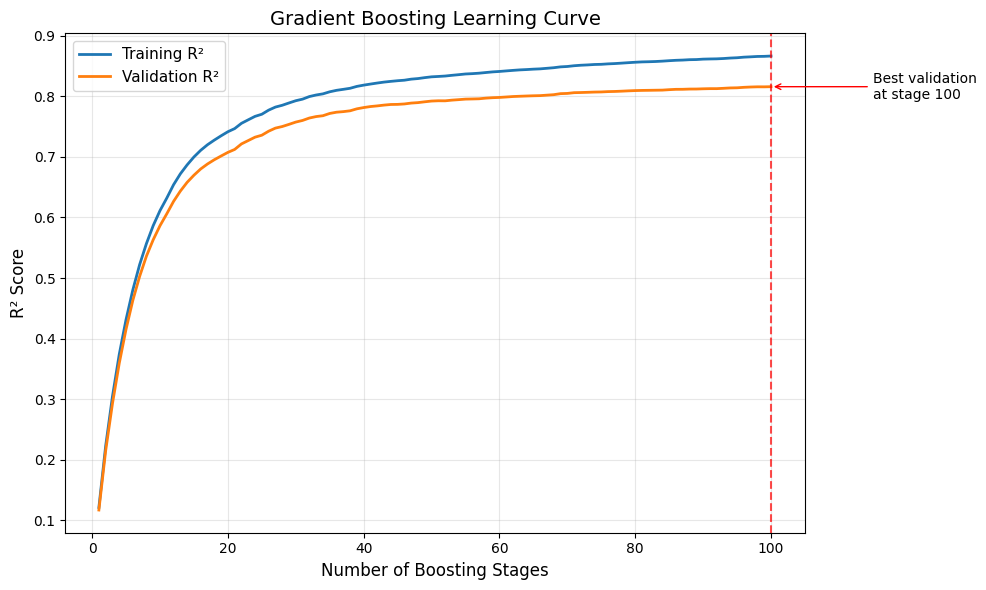

Notice: Training score keeps improving, but validation can plateau or decline.
This is why early stopping is important for gradient boosting!


In [21]:
# Show how boosting improves with more stages
train_scores = []
valid_scores = []

# Use staged_predict to get predictions at each boosting stage
for i, (train_pred, valid_pred) in enumerate(zip(
    gb.staged_predict(X_train), gb.staged_predict(X_valid)
)):
    train_scores.append(r2_score(y_train, train_pred))
    valid_scores.append(r2_score(y_valid, valid_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_scores, label='Training R²', linewidth=2)
plt.plot(range(1, 101), valid_scores, label='Validation R²', linewidth=2)
plt.xlabel('Number of Boosting Stages', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Gradient Boosting Learning Curve', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Mark where validation peaks
best_stage = np.argmax(valid_scores) + 1
plt.axvline(x=best_stage, color='red', linestyle='--', alpha=0.7)
plt.annotate(f'Best validation\nat stage {best_stage}', 
             xy=(best_stage, valid_scores[best_stage-1]),
             xytext=(best_stage + 15, valid_scores[best_stage-1] - 0.02),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print(f"Notice: Training score keeps improving, but validation can plateau or decline.")
print(f"This is why early stopping is important for gradient boosting!")

---

## 13. Final Comparison: Which Method Wins?

Let's put all our methods head-to-head.

In [22]:
print("\n" + "="*60)
print(" FINAL MODEL COMPARISON ")
print("="*60)
print(f"{'Model':<25} {'Valid R²':>12} {'Valid RMSE':>15}")
print("-"*60)

models = [
    ('Single Decision Tree', valid_r2, np.sqrt(mean_squared_error(y_valid, tree.predict(X_valid)))),
    ('Bagging (50 trees)', bag_valid_r2, np.sqrt(mean_squared_error(y_valid, bag.predict(X_valid)))),
    ('Random Forest (100 trees)', rf_valid_r2, rf_rmse),
    ('Gradient Boosting', gb_valid_r2, gb_rmse),
]

for name, r2, rmse in models:
    rmse_dollars = f"${rmse * 100000:,.0f}"
    print(f"{name:<25} {r2:>12.4f} {rmse_dollars:>15}")

print("="*60)
print("\nWinner: Gradient Boosting (but Random Forest is very close!)")


 FINAL MODEL COMPARISON 
Model                         Valid R²      Valid RMSE
------------------------------------------------------------
Single Decision Tree            0.5997         $72,423
Bagging (50 trees)              0.6469         $68,026
Random Forest (100 trees)       0.7734         $54,487
Gradient Boosting               0.8160         $49,109

Winner: Gradient Boosting (but Random Forest is very close!)


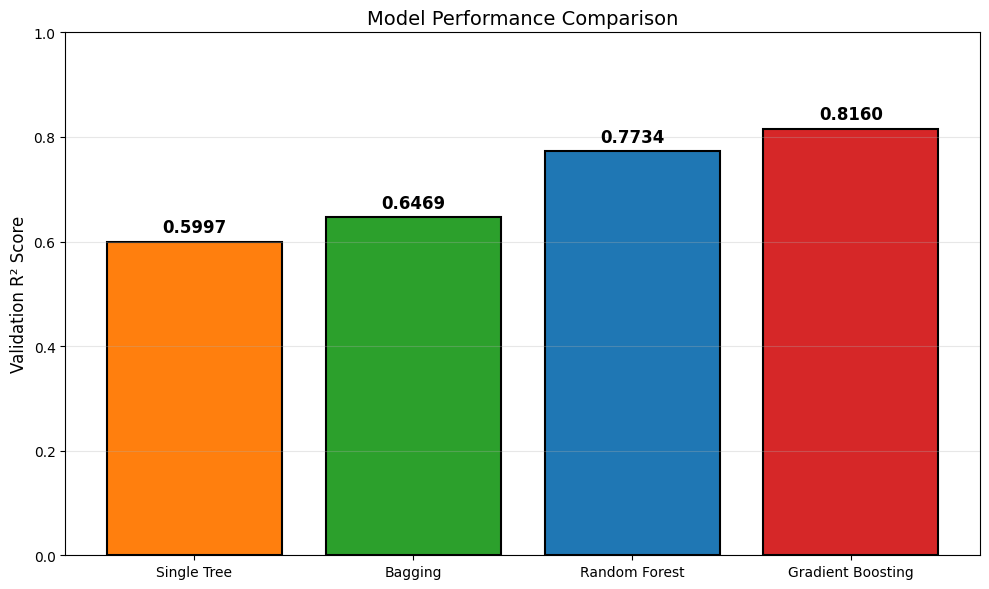

In [23]:
# Visual comparison
model_names = ['Single Tree', 'Bagging', 'Random Forest', 'Gradient Boosting']
r2_scores = [valid_r2, bag_valid_r2, rf_valid_r2, gb_valid_r2]
colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, r2_scores, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Validation R² Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 14. When to Use What: A Practical Guide

### Use Tree-Based Ensembles (Random Forest, XGBoost) When:

- Working with **tabular/structured data** (spreadsheets, databases)
- **Interpretability matters** (need to explain predictions)
- **Fast iteration** is needed (no GPU required)
- Data has **mixed types** (numerical + categorical)
- You need **prediction confidence** estimates
- Data may have **missing values** or **outliers**

### Use Neural Networks When:

- Working with **unstructured data** (images, text, audio)
- You have **very large datasets** (millions of examples)
- **Transfer learning** is available (pretrained models)
- You need to **extrapolate** beyond training data range
- Data has **high-cardinality categoricals** (embeddings help)

### Random Forest vs Gradient Boosting

| Factor | Random Forest | Gradient Boosting |
|--------|--------------|-------------------|
| Ease of use | Easier (less tuning) | Requires more tuning |
| Training speed | Faster (parallel) | Slower (sequential) |
| Overfitting risk | Low | Higher (needs early stopping) |
| Peak performance | Very good | Often slightly better |
| Interpretability | Good | Good |

---

## Exercises

### Exercise 1: Overfitting Analysis
Plot train vs validation R² for Random Forest as `max_depth` varies from 3 to 30. At what depth does overfitting become visible?

### Exercise 2: Feature Engineering
Create a new feature `rooms_per_person = AveRooms / AveOccup`. Retrain the Random Forest and measure:
- Does the new feature appear in the top 5 by importance?
- Does overall model performance improve?

### Exercise 3: XGBoost Comparison
Install XGBoost (`pip install xgboost`) and compare its performance to sklearn's GradientBoostingRegressor. Is it faster? More accurate?

### Exercise 4: Confidence-Based Filtering
Using the prediction confidence (tree std) from Section 9:
- Filter predictions to only include the 50% most confident
- What is the R² on just these confident predictions?
- How might you use this in a real application?

---

## Summary

### Key Takeaways

1. **Ensembles work by averaging out errors** from diverse base learners
2. **Bagging** creates diversity via bootstrap sampling
3. **Random Forests** add feature randomization for even more diversity
4. **OOB error** gives free validation without holding out data
5. **Permutation importance** is more reliable than default feature importance
6. **Partial dependence** shows how features affect predictions
7. **Tree disagreement** provides prediction confidence
8. **Trees cannot extrapolate**—a critical limitation
9. **Gradient Boosting** learns sequentially, often achieving slightly better performance

### Next Steps

- Try **XGBoost** or **LightGBM** for production gradient boosting
- Explore **SHAP values** for more sophisticated feature importance
- Learn about **model stacking** to combine different model types
- Practice on Kaggle competitions—tabular competitions are dominated by tree ensembles!

---

## References

### Academic Papers
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5-32.
- Breiman, L. (1996). Bagging Predictors. *Machine Learning*, 24(2), 123-140.
- Friedman, J.H. (2001). Greedy Function Approximation: A Gradient Boosting Machine.

### Books & Courses
- [Fast.ai Practical Deep Learning, Lesson 6: Random Forests](https://course.fast.ai/Lessons/lesson6.html)
- [Fastbook Chapter 9: Tabular Modeling Deep Dive](https://github.com/fastai/fastbook/blob/master/09_tabular.ipynb)
- Raschka, S., Liu, Y., & Mirjalili, V. (2022). Machine Learning with PyTorch and Scikit-Learn, Chapter 7.

### Practical Resources
- [Beware Default Random Forest Importances](https://explained.ai/rf-importance/) - Parr et al.
- [XGBoost Documentation](https://xgboost.readthedocs.io/)
- [LightGBM Documentation](https://lightgbm.readthedocs.io/)